In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob

In [ ]:
# ---------- hjælp: boxcount + fraktal-dimension ----------
def boxcount(Z, k):
    S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_image(filename, t=150, plot=True):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    Z = (I < t).astype(int)

    p = min(Z.shape)
    n = int(np.floor(np.log2(p)))
    sizes = 2**np.arange(n, 1, -1)

    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)

    x = np.log(1.0 / sizes)
    y = np.log(counts)
    D, a = np.polyfit(x, y, 1)

    if plot:
        plt.figure(figsize=(5,4))
        plt.plot(x, y, 'o-', label='data')
        plt.plot(x, a + D*x, 'r--', label=f'fit, D={D:.3f}')
        plt.xlabel("log(1/box size)")
        plt.ylabel("log(N(boxes))")
        plt.legend()
        plt.title(filename)
        plt.tight_layout()
        plt.show()

    return D

extensions = ("*.jpg", "*.png")
files = sorted([f for ext in extensions for f in glob.glob(ext)])

results = []
for f in files:
    D = fractal_dimension_image(f, t=150, plot=False) 
    results.append((f, D))

print("Fil\t\tFraktal-dimension")
for f, D in results:
    print(f"{f}\t{D:.3f}")

NameError: name 'glob' is not defined

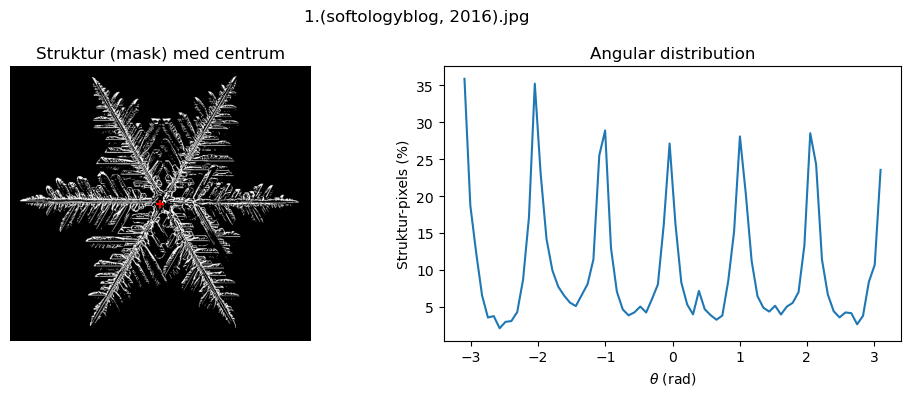

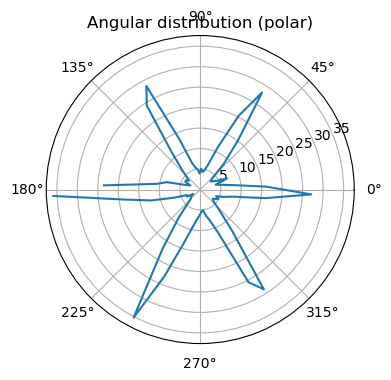

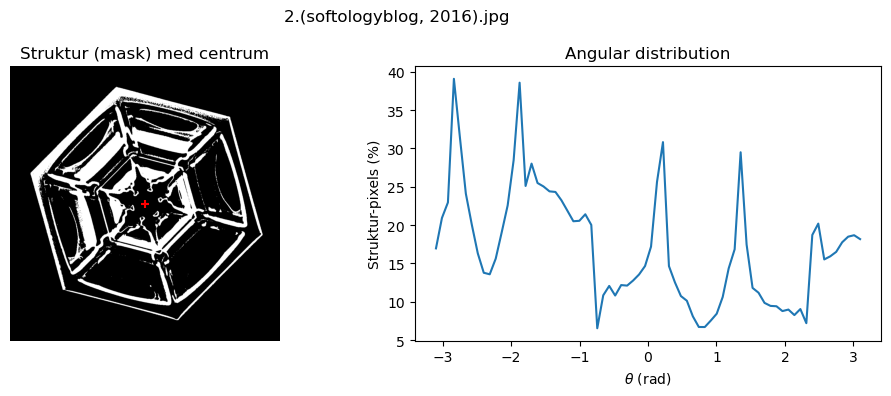

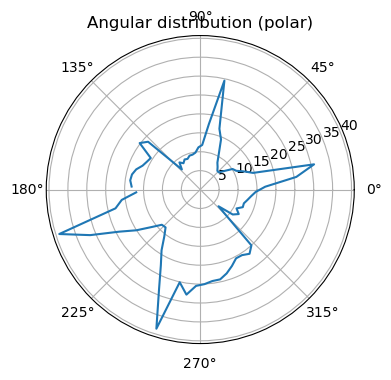

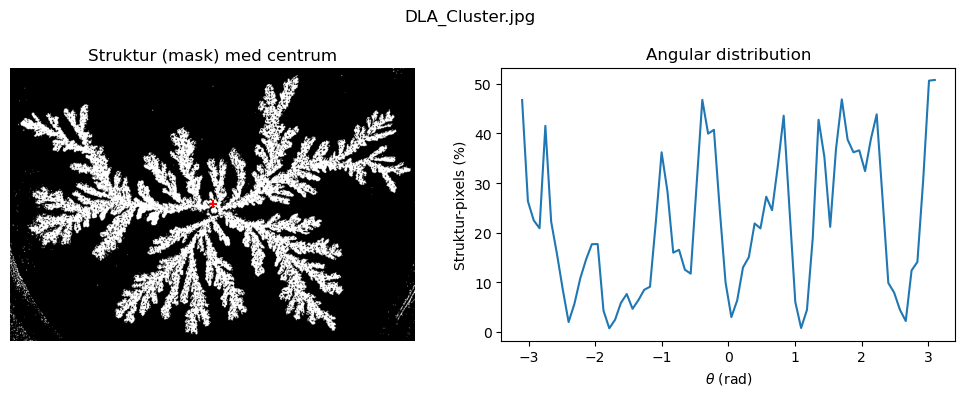

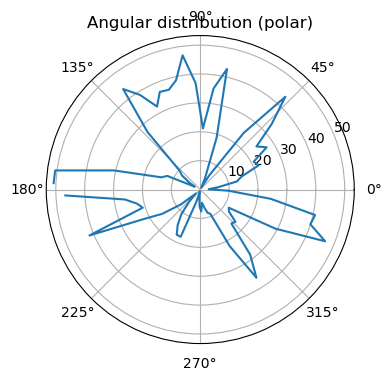

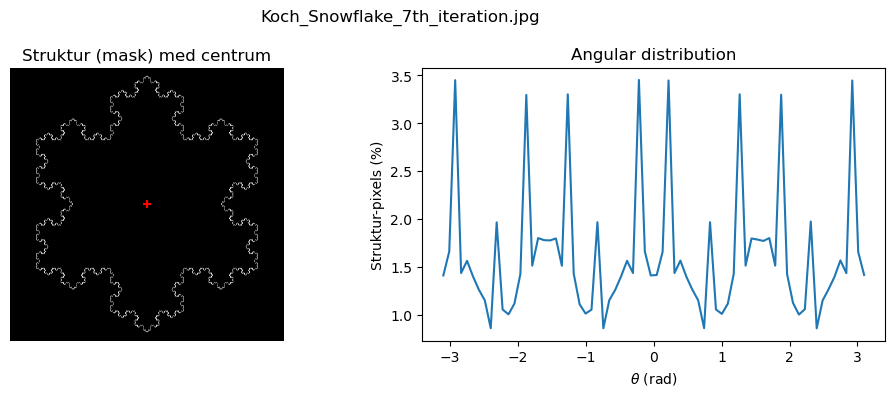

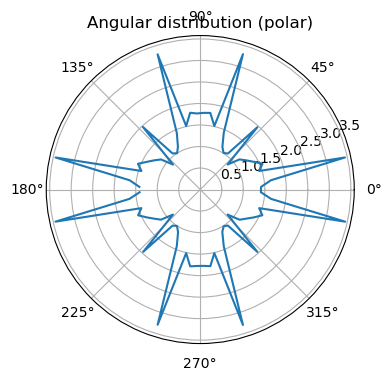

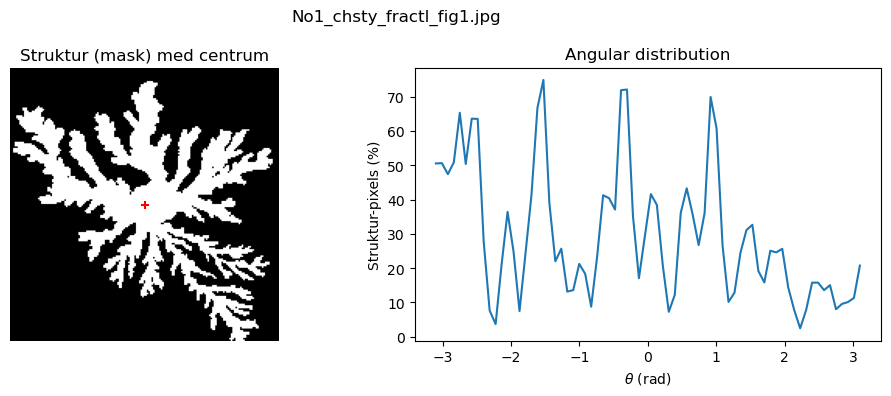

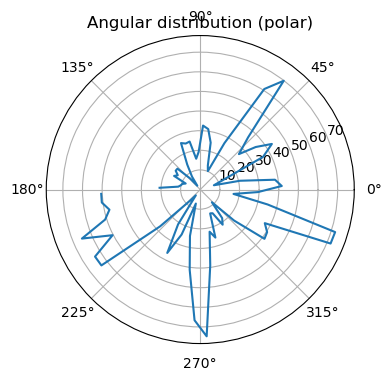

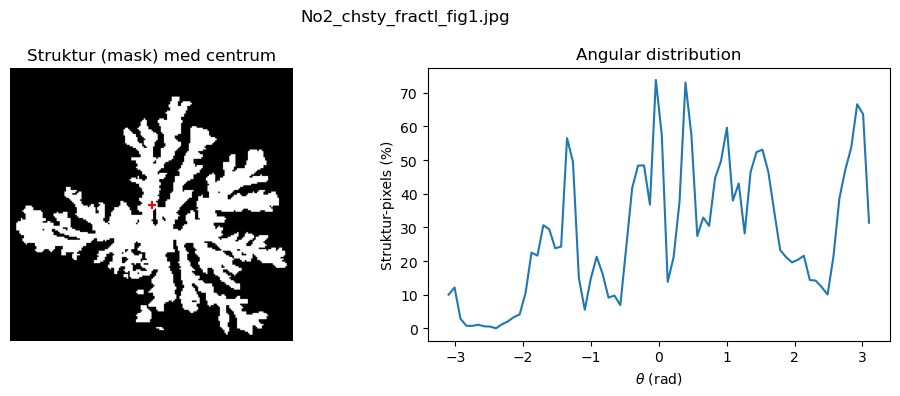

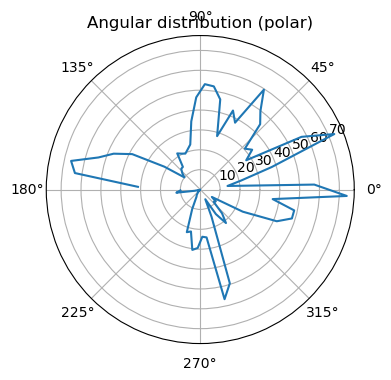

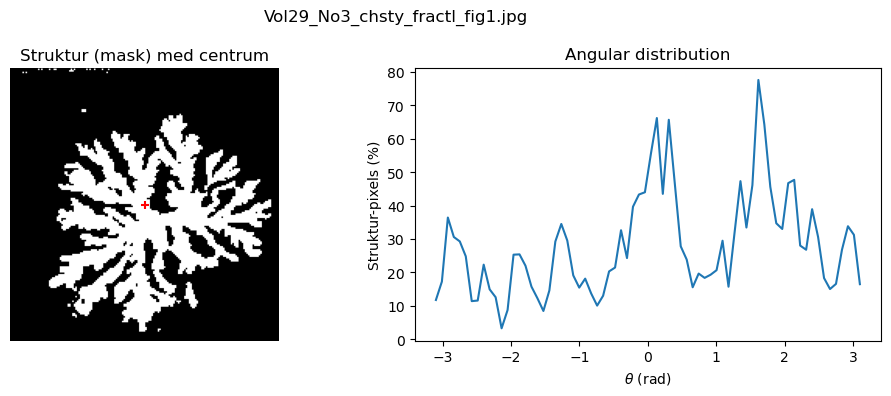

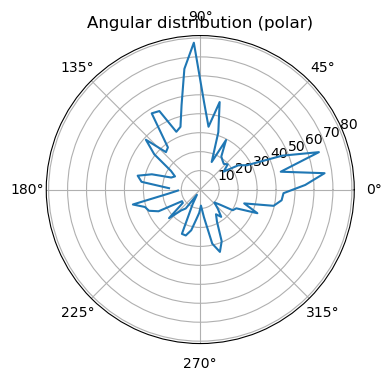

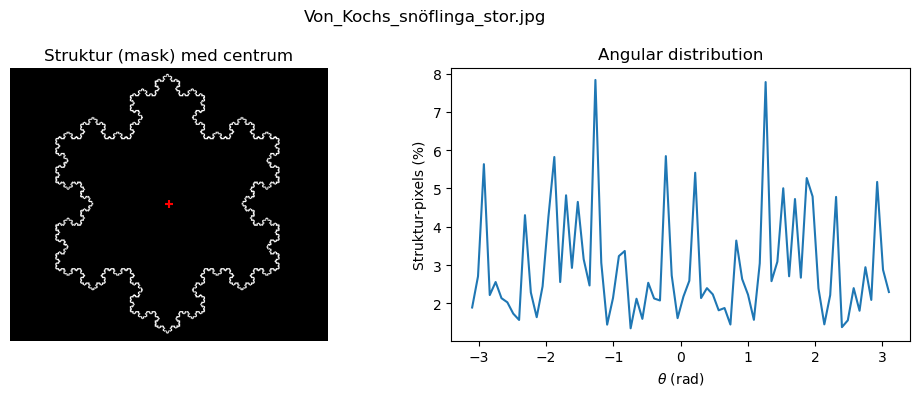

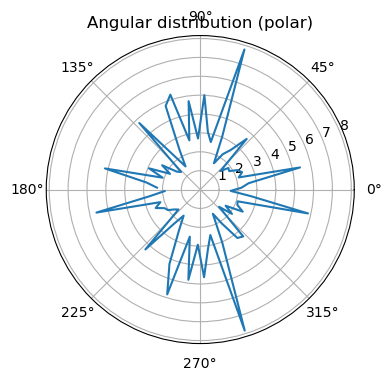

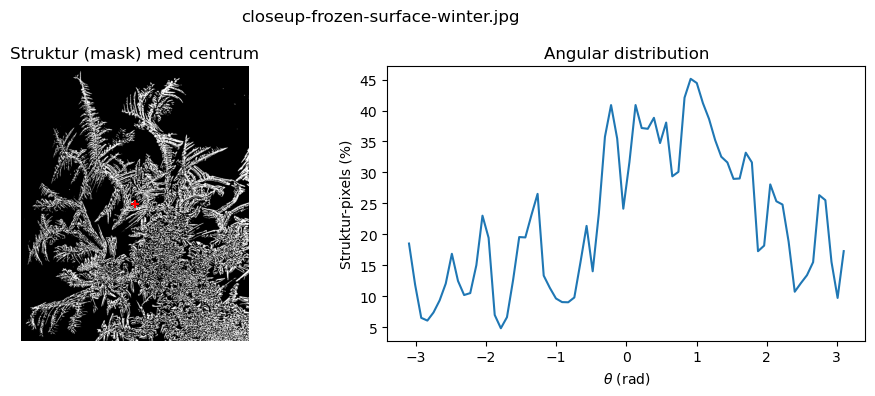

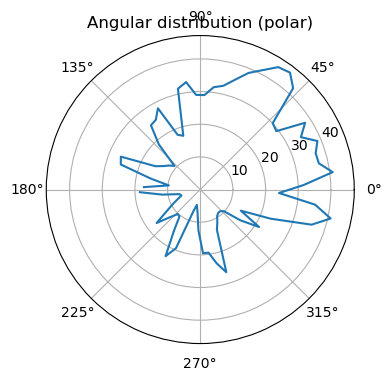

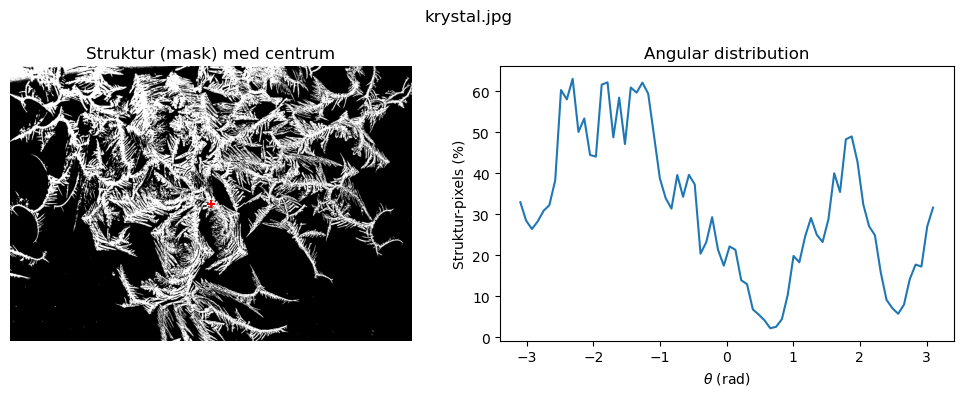

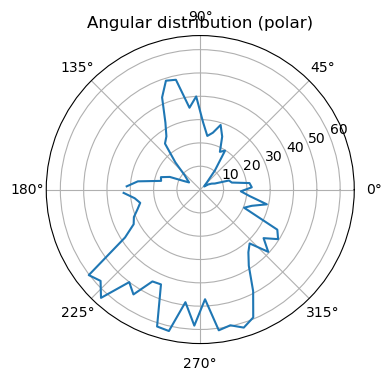

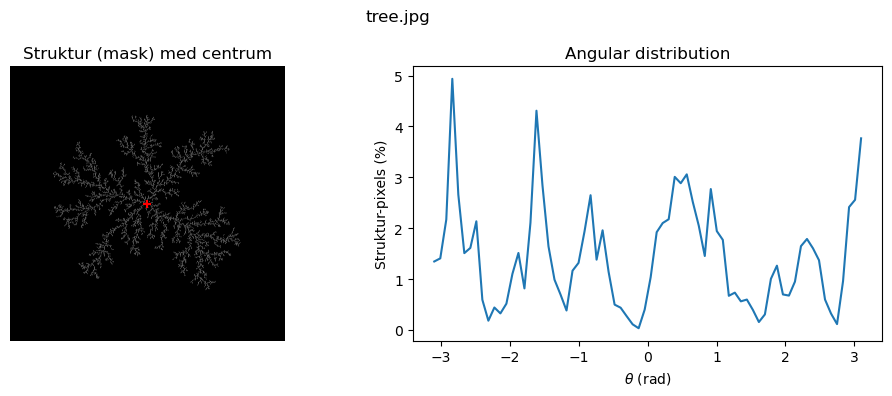

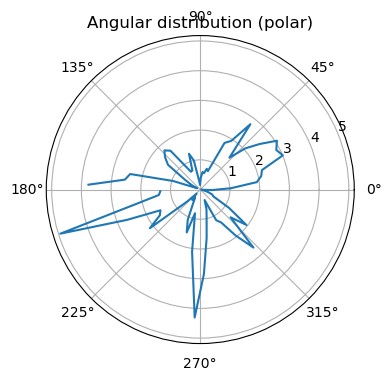

In [ ]:
# ----------angular distribution----------
def angular_distribution(filename, t=150, nbins=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    # vinkel i [-pi, pi]
    theta = np.arctan2(y - cy, x - cx)

    struct_mask = (I < t).astype(float)

    bin_edges = np.linspace(-np.pi, np.pi, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    N_total, _ = np.histogram(theta, bins=bin_edges)               
    N_struct, _ = np.histogram(theta, bins=bin_edges, weights=struct_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]  

    return bin_centers, frac_struct, struct_mask, (cx, cy)


extensions = ("*.jpg", "*.png")
files = sorted([f for ext in extensions for f in glob.glob(ext)])

for f in files:
    th, frac_theta, mask, (cx, cy) = angular_distribution(f, t=150, nbins=72)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f)

    # billede / struktur + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Struktur (mask) med centrum")
    axs[0].axis("off")

    # vinkel-fordeling (kan også tegnes som polær)
    axs[1].plot(th, frac_theta)
    axs[1].set_xlabel(r"$\theta$ (rad)")
    axs[1].set_ylabel("Struktur-pixels (%)")
    axs[1].set_title("Angular distribution")

    plt.tight_layout()
    plt.show()

    # alternativ: polært plot
    plt.figure(figsize=(4,4))
    axp = plt.subplot(111, projection="polar")
    axp.plot(th, frac_theta)
    axp.set_title("Angular distribution (polar)")
    plt.show()

In [ ]:
#---------- radial masse og centrum----------

def radial_mass_and_color(filename, t=150, dr=1.0):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    r_max = r.max()
    nbins = int(r_max // dr)
    bin_edges = np.linspace(0, r_max, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    structure_mask = (I < t).astype(float) 

    deltaM, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)
    M = np.cumsum(deltaM)
    Mf = deltaM / (2 * np.pi * bin_centers * dr)

    N_total, _ = np.histogram(r, bins=bin_edges)
    N_struct, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]

    return bin_centers, M, Mf, structure_mask, cx, cy, frac_struct


extensions = ("*.jpg", "*.png")
files = sorted([f for ext in extensions for f in glob.glob(ext)])

for f in files:
    r, M, Mf, mask, cx, cy, frac_color = radial_mass_and_color(f, t=150, dr=1.0)

    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f)

    # 1) binært billede + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Binært billede")
    axs[0].axis("off")

    # 2) M(r)
    axs[1].plot(r, M)
    axs[1].set_xlabel("r (pixels)")
    axs[1].set_ylabel("M(r)")
    axs[1].set_title("Samlet masse M(r)")

    # 3) M_f(r)
    axs[2].plot(r, Mf)
    axs[2].set_xlabel("r (pixels)")
    axs[2].set_ylabel("M_f(r)")
    axs[2].set_title("Radial massetæthed M_f(r)")

    # 4) procent farvede pixels

    axs[3].plot(r, frac_color)
    axs[3].set_xlabel("r (pixels)")
    axs[3].set_ylabel("Masse-pixels (%)")
    axs[3].set_ylim(0, 1.1 * frac_color.max())
    axs[3].set_title("Procent masse-pixels")

    plt.tight_layout()
    plt.show()




NameError: name 'glob' is not defined

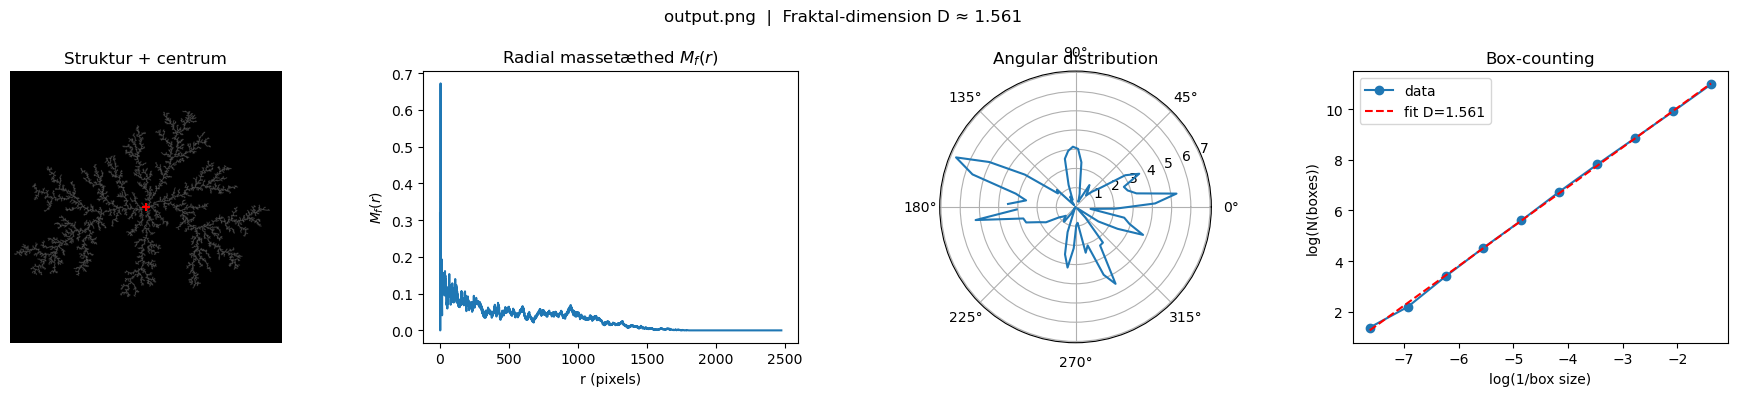

output.png: D ≈ 1.561


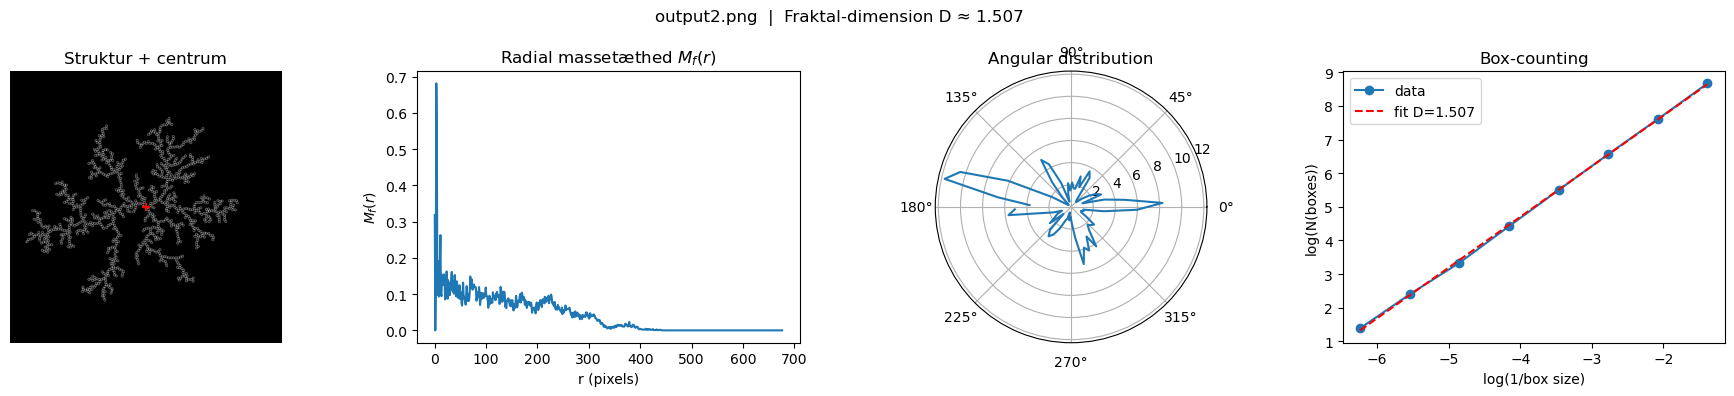

output2.png: D ≈ 1.507


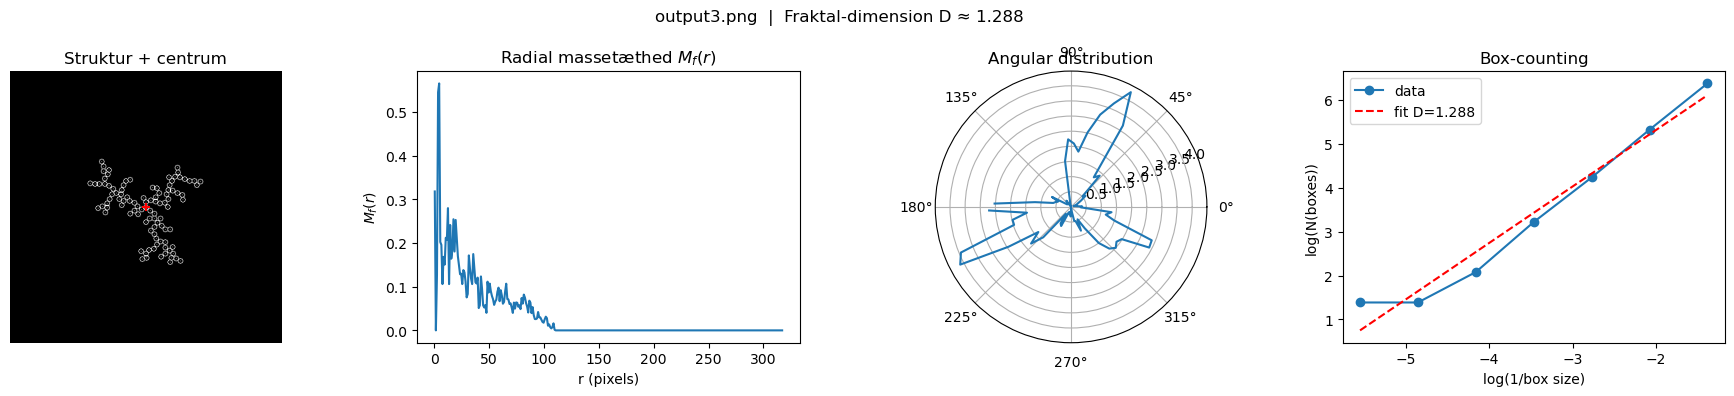

output3.png: D ≈ 1.288


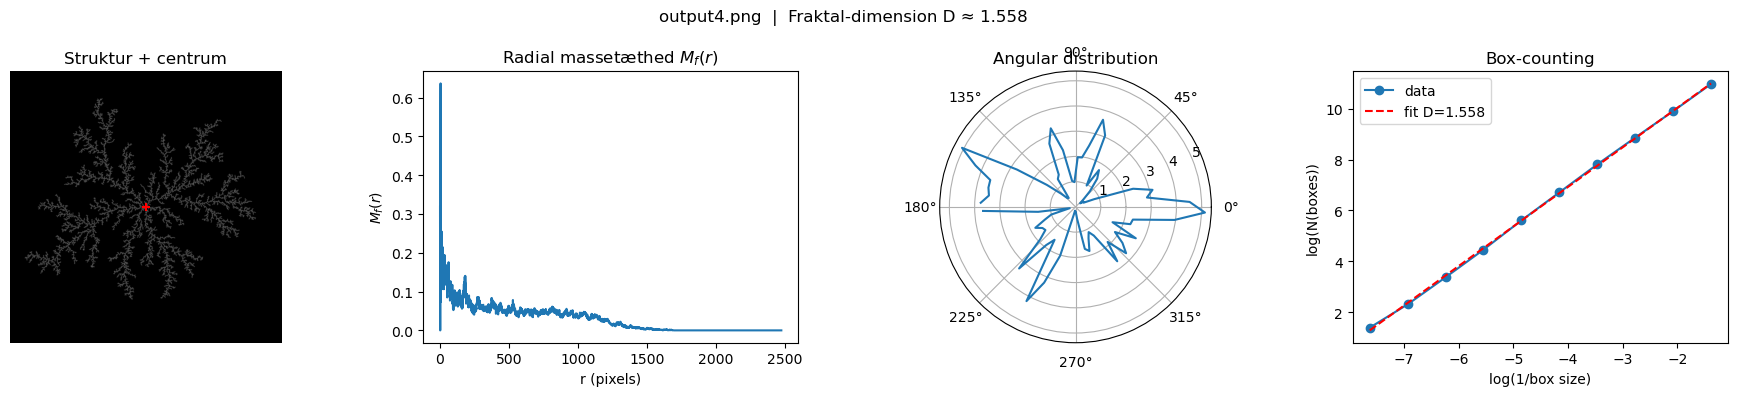

output4.png: D ≈ 1.558


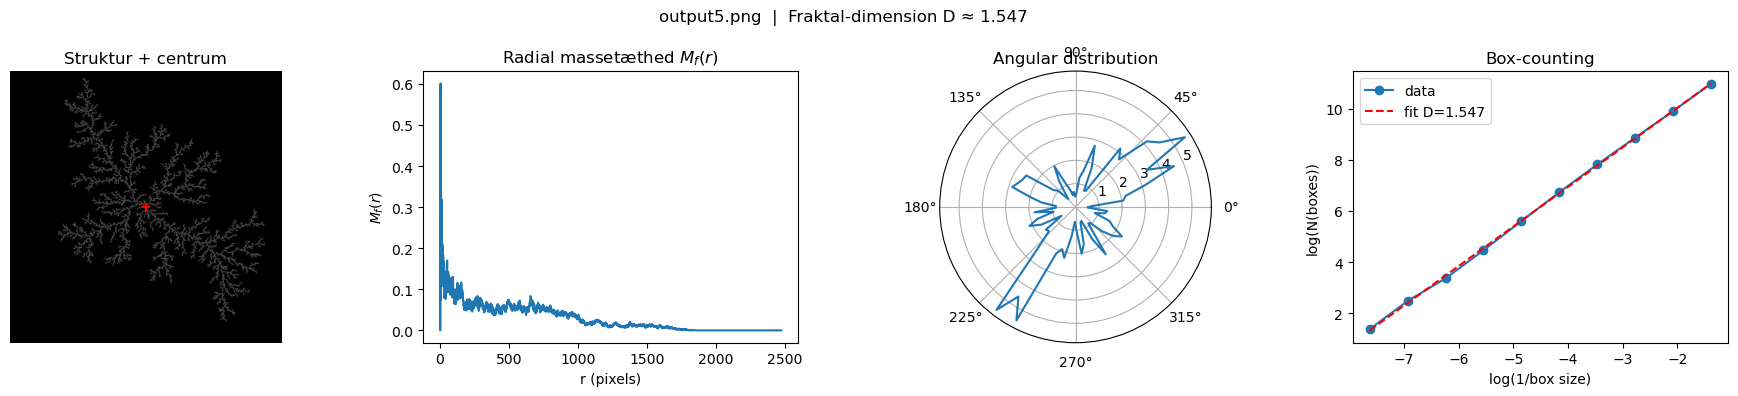

output5.png: D ≈ 1.547


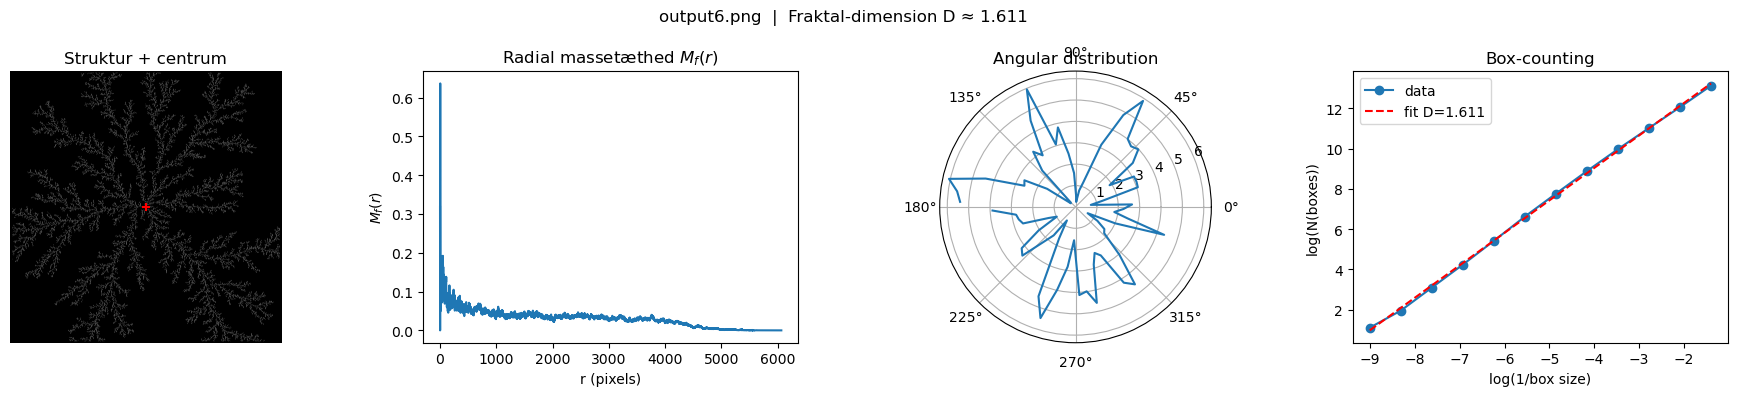

output6.png: D ≈ 1.611


DecompressionBombError: Image size (290702500 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.

In [8]:
# ---------- samlede analyser for ét billede ----------

# ---------- boxcount + fraktal-dimension ----------

def boxcount(Z, k):
    S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_from_mask(Z):
    p = min(Z.shape)
    n = int(np.floor(np.log2(p)))
    sizes = 2**np.arange(n, 1, -1)
    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)

    x = np.log(1.0 / sizes)
    y = np.log(counts)
    D, a = np.polyfit(x, y, 1)
    return D, x, y, a

# ---------- hovedanalyse for ét billede ----------

def analyse_billede(filename, t=150, dr=1.0, nbins_theta=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    theta = np.arctan2(y - cy, x - cx)

    # struktur = mørke pixels
    struct_mask = (I < t).astype(float)

    # ---------- radial massefordeling M_f(r) ----------
    r_max = r.max()
    nbins_r = int(r_max // dr)
    bin_edges_r = np.linspace(0, r_max, nbins_r + 1)
    r_centers = 0.5 * (bin_edges_r[:-1] + bin_edges_r[1:])

    deltaM, _ = np.histogram(r, bins=bin_edges_r, weights=struct_mask)
    Mf = deltaM / (2 * np.pi * r_centers * dr)

    # ---------- angular distribution (polar) ----------
    bin_edges_th = np.linspace(-np.pi, np.pi, nbins_theta + 1)
    th_centers = 0.5 * (bin_edges_th[:-1] + bin_edges_th[1:])
    N_tot_th, _ = np.histogram(theta, bins=bin_edges_th)
    N_struct_th, _ = np.histogram(theta, bins=bin_edges_th, weights=struct_mask)
    frac_theta = np.zeros_like(th_centers)
    valid_th = N_tot_th > 0
    frac_theta[valid_th] = 100.0 * N_struct_th[valid_th] / N_tot_th[valid_th]

    # ---------- fraktal-dimension (box-counting) ----------
    Z = (struct_mask > 0).astype(int)
    D, x_log, y_log, a = fractal_dimension_from_mask(Z)

    # ---------- samlet figur med 4 akser ----------
    fig = plt.figure(figsize=(18, 4))
    fig.suptitle(f"{filename}  |  Fraktal-dimension D ≈ {D:.3f}")

    # 1) struktur + centrum
    ax1 = plt.subplot(1, 4, 1)
    ax1.imshow(struct_mask, cmap="gray")
    ax1.scatter([cx], [cy], c="red", s=40, marker="+")
    ax1.set_title("Struktur + centrum")
    ax1.axis("off")

    # 2) radial massetæthed M_f(r)
    ax2 = plt.subplot(1, 4, 2)
    ax2.plot(r_centers, Mf)
    ax2.set_xlabel("r (pixels)")
    ax2.set_ylabel(r"$M_f(r)$")
    ax2.set_title("Radial massetæthed $M_f(r)$")

    # 3) angular distribution (polar)
    ax3 = plt.subplot(1, 4, 3, projection="polar")
    ax3.plot(th_centers, frac_theta)
    ax3.set_title("Angular distribution")

    # 4) box-counting plot
    ax4 = plt.subplot(1, 4, 4)
    ax4.plot(x_log, y_log, "o-", label="data")
    ax4.plot(x_log, a + D * x_log, "r--", label=f"fit D={D:.3f}")
    ax4.set_xlabel("log(1/box size)")
    ax4.set_ylabel("log(N(boxes))")
    ax4.set_title("Box-counting")
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # kun D returneres (ingen ekstra plot)
    return D
# ---------- kør for alle billeder i mappen ----------
extensions = ("*.jpg", "*.png")
files = sorted([f for ext in extensions for f in glob.glob(ext)])
for f in files:
    D = analyse_billede(f, t=150, nbins_theta=72)
    print(f"{f}: D ≈ {D:.3f}")